# Ray Calculation

Current step as of Fri Aug 7: Seems to be a units issue or some scale problem for the IAT. Gets bigger instead of smaller

In [114]:
import numpy as np
from astropy import units as u

In [115]:
pwd

'/Users/iman/Documents/cuny_ms/csm_pipeline'

In [116]:
import csv

csm_2d_density_list = []
with open("csm_2d_density.csv") as csvfile:
    reader = csv.reader(csvfile, quoting=csv.QUOTE_NONNUMERIC) # change contents to floats
    for row in reader: # each row is a list
        csm_2d_density_list.append(row)

In [117]:
csm_2d_density = np.array(csm_2d_density_list)


In [163]:
csm_2d_density[np.isnan(csm_2d_density)] = 0



In [164]:
csm_2d_density.shape

(1000, 1000)

In [165]:
np.max(csm_2d_density)

0.00024578104746353477

In [166]:
center_x = 499
center_y = 499
pix_size_arcsec = 0.005*u.arcsec

In [167]:
from matplotlib import pyplot as plt

In [168]:
csm_2d_density[499,499]

0.0

In [169]:
csm_2d_density[a:b,a:b][499-440,499-560]

0.0

In [170]:
csm_2d_density[a:b,a:b][cx-a,cy-b]

0.0

In [171]:
csm_2d_density[a:b,a:b].shape

(120, 120)

In [172]:
print(cx-a,cy-a)

59 59


Text(0, 0.5, '$\\Delta$ Dec (arc)')

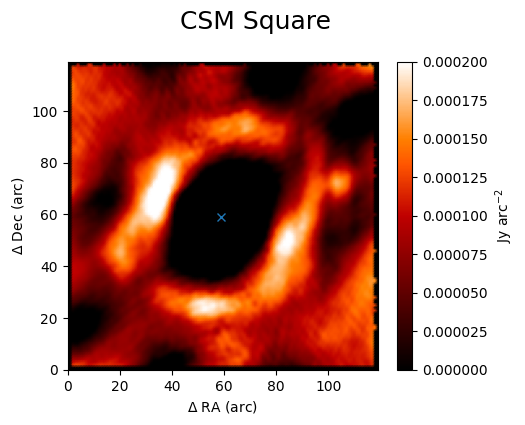

In [173]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

a=440
b=560

im = ax.pcolormesh(csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

# ax.set_xlim(a,b)
# ax.set_ylim(a,b)
ax.plot(cx-a,cy-a,'x')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [174]:
import sys

In [175]:
np.set_printoptions(threshold=sys.maxsize)

In [176]:
csm_2d_density[a:b,a:b]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+0

Text(0, 0.5, '$\\Delta$ Dec (arc)')

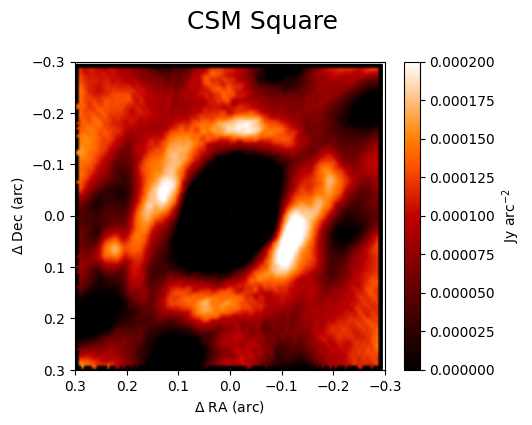

In [177]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis1[a:b],yaxis1[a:b],csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [178]:
from radial_interpolation import *

In [179]:
pix_size_arcsec

<Quantity 0.005 arcsec>

In [180]:
lines = 201
points = 100

In [181]:
cx

59

59 59 0.005 arcsec True


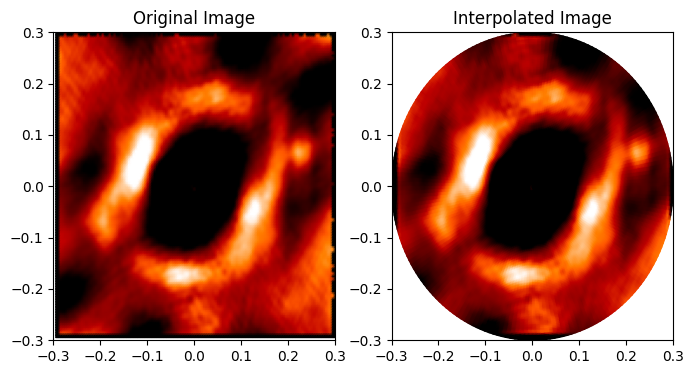

In [182]:
x_grid,y_grid,interp_csm = radial_interp(csm_2d_density[a:b,a:b], 59,59,
              n_lines = lines, n_pts = points, pix_arc = pix_size_arcsec,plot_bool=True,vmax=0.0002)

In [183]:
np.max(x_grid)

119.0

In [184]:
interp_csm.shape

(201, 100)

In [185]:
interp_csm

array([[ 5.91682083e-22, -2.11240882e-05, -5.54827029e-05,
        -1.04909199e-04, -1.74901596e-04, -2.68348044e-04,
        -3.83223285e-04, -5.06753777e-04, -6.33342245e-04,
        -7.67842090e-04, -8.99072201e-04, -1.00968457e-03,
        -1.08986518e-03, -1.13496848e-03, -1.14467508e-03,
        -1.11899588e-03, -1.06008374e-03, -9.75499074e-04,
        -8.73784079e-04, -7.63422014e-04, -6.51732130e-04,
        -5.44611852e-04, -4.45711867e-04, -3.56838105e-04,
        -2.78638675e-04, -2.12807556e-04, -1.59692279e-04,
        -1.16336491e-04, -7.99084226e-05, -4.85199680e-05,
        -2.28396585e-05, -2.59923568e-06,  1.52145073e-05,
         3.25700661e-05,  4.99471441e-05,  6.54511895e-05,
         7.83962642e-05,  9.05823570e-05,  1.02039468e-04,
         1.11755897e-04,  1.19168252e-04,  1.24370132e-04,
         1.28210858e-04,  1.31829883e-04,  1.36304792e-04,
         1.42110547e-04,  1.48142434e-04,  1.52030913e-04,
         1.54407556e-04,  1.57134148e-04,  1.61588316e-0

Text(0.5, 1.0, 'Interpolated Image')

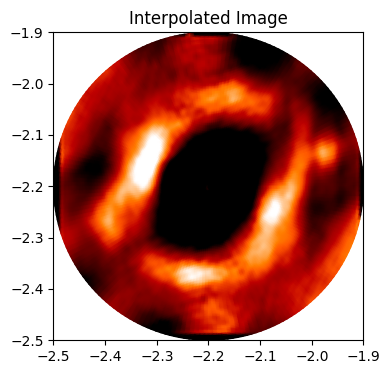

In [186]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
xaxis = x_grid*pix_size_arcsec.value-(center_x*pix_size_arcsec.value)
yaxis = y_grid*pix_size_arcsec.value-(center_y*pix_size_arcsec.value)
ax.pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

# rnge = 0.3
# ax.set_xlim(-rnge,rnge)
# ax.set_ylim(-rnge,rnge)


ax.set_title("Interpolated Image")

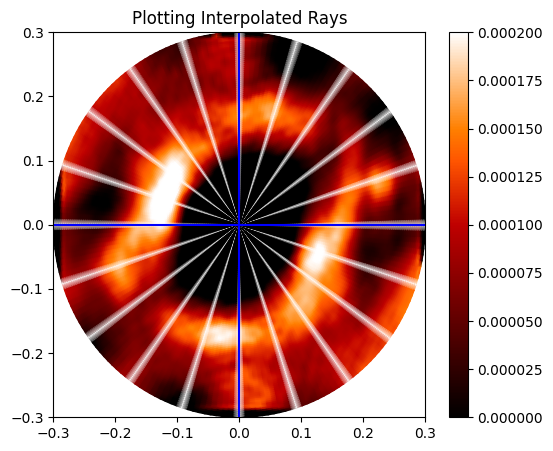

In [187]:
plot_rays(x_grid,y_grid,interp_csm,vmax=0.0002)


# Inverse Abel Transform

In [188]:
from abel import do_abel

In [189]:
interp_csm.shape

(201, 100)

In [190]:
interp_csm[0,:].shape
interp_csm[:,0].shape

(201,)

In [191]:
csm_2d_density[cy,:]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [192]:
from radial import sm

In [193]:
x_pc = sm(168,xaxis)*u.pc
y_pc = sm(168,yaxis)*u.pc

In [194]:
x_pc.shape

(201, 100)

In [195]:
radius_2d_pc = np.array([[0.0]*x_pc.shape[1]]*x_pc.shape[0])
#fill pc array of radii
for i in range(x_pc.shape[0]):
        for j in range(x_pc.shape[1]):
            c = (x_pc[i,j].value)**2+(y_pc[i,j].value)**2
            radius_2d_pc[i,j] = np.sqrt(c)

In [196]:
xaxis.shape

(201, 100)

In [197]:
radius_2d_arc = np.array([[0.0]*xaxis.shape[1]]*xaxis.shape[0])
#fill pc array of radii
for i in range(xaxis.shape[0]):
        for j in range(xaxis.shape[1]):
            c = (xaxis[i,j])**2+(yaxis[i,j])**2
            radius_2d_arc[i,j] = np.sqrt(c)

In [198]:
interp_csm.shape

(201, 100)

In [199]:
radius_2d_arc.shape

(201, 100)

In [200]:
interp_csm

array([[ 5.91682083e-22, -2.11240882e-05, -5.54827029e-05,
        -1.04909199e-04, -1.74901596e-04, -2.68348044e-04,
        -3.83223285e-04, -5.06753777e-04, -6.33342245e-04,
        -7.67842090e-04, -8.99072201e-04, -1.00968457e-03,
        -1.08986518e-03, -1.13496848e-03, -1.14467508e-03,
        -1.11899588e-03, -1.06008374e-03, -9.75499074e-04,
        -8.73784079e-04, -7.63422014e-04, -6.51732130e-04,
        -5.44611852e-04, -4.45711867e-04, -3.56838105e-04,
        -2.78638675e-04, -2.12807556e-04, -1.59692279e-04,
        -1.16336491e-04, -7.99084226e-05, -4.85199680e-05,
        -2.28396585e-05, -2.59923568e-06,  1.52145073e-05,
         3.25700661e-05,  4.99471441e-05,  6.54511895e-05,
         7.83962642e-05,  9.05823570e-05,  1.02039468e-04,
         1.11755897e-04,  1.19168252e-04,  1.24370132e-04,
         1.28210858e-04,  1.31829883e-04,  1.36304792e-04,
         1.42110547e-04,  1.48142434e-04,  1.52030913e-04,
         1.54407556e-04,  1.57134148e-04,  1.61588316e-0

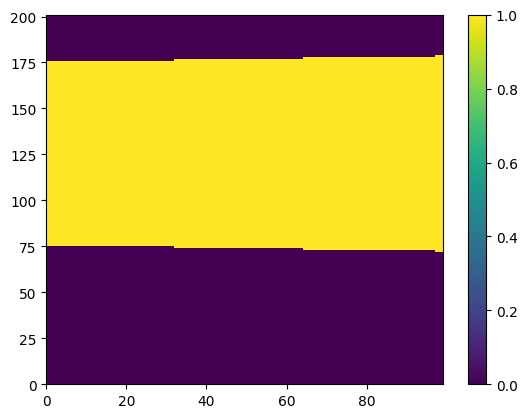

In [218]:
plt.pcolormesh(np.diff(radius_2d_arc)>0)
plt.colorbar()

In [224]:
radius_2d_arc[0][::-1]

array([2.90688837, 2.90886994, 2.91085332, 2.9128385 , 2.91482547,
       2.91681424, 2.9188048 , 2.92079715, 2.92279129, 2.9247872 ,
       2.92678489, 2.92878435, 2.93078558, 2.93278858, 2.93479334,
       2.93679986, 2.93880813, 2.94081815, 2.94282992, 2.94484343,
       2.94685869, 2.94887568, 2.9508944 , 2.95291486, 2.95493704,
       2.95696094, 2.95898656, 2.9610139 , 2.96304295, 2.9650737 ,
       2.96710617, 2.96914033, 2.97117619, 2.97321375, 2.975253  ,
       2.97729393, 2.97933655, 2.98138085, 2.98342683, 2.98547448,
       2.9875238 , 2.98957478, 2.99162744, 2.99368175, 2.99573771,
       2.99779533, 2.9998546 , 3.00191552, 3.00397808, 3.00604228,
       3.00810811, 3.01017558, 3.01224468, 3.0143154 , 3.01638775,
       3.01846171, 3.02053729, 3.02261449, 3.02469329, 3.0267737 ,
       3.02885571, 3.03093933, 3.03302454, 3.03511134, 3.03719973,
       3.0392897 , 3.04138127, 3.04347441, 3.04556912, 3.04766541,
       3.04976327, 3.0518627 , 3.05396369, 3.05606624, 3.05817

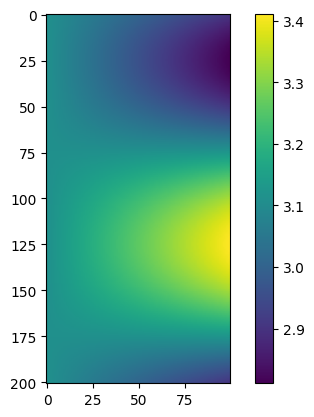

In [212]:
plt.imshow(radius_2d_arc)
plt.colorbar()

In [ ]:
csm_abel = []
r_arr = np.zeros(len(interp_csm[i,:]))
row = np.zeros(len(interp_csm[i,:]))
radius_interp = 
m = 0

for i in range(len(interp_csm[:,0])):
    row = np.zeros(len(interp_csm[i,:]))

    #row = do_abel(interp_csm[i,:],radius_2d_arc[i,:],8.7055651*10-5)
    F = interp_csm[i,:]
    F[F<0]=0
    s = radius_2d_arc[i,:]
    dF_ds = np.gradient(F,s)
    print(i)
    print(len(s)-1)

    for j in range(len(s)-1):
            r = (s[j]+s[j+1])/2
            r_arr[j] = r
            print(r)
            print(s)
            print(dF_ds[j+1:].shape)
            print(np.sqrt(s[s>r]**2-r**2).shape)
            print(s[s>r])
            integ = np.trapz(dF_ds[j+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])
    
            row[j]= (-1/np.pi)* integ


    csm_abel.append(row)


0
99
3.110198832494546
[3.11126984 3.10912783 3.1069873  3.10484825 3.10271068 3.10057461
 3.09844002 3.09630693 3.09417534 3.09204525 3.08991666 3.08778957
 3.085664   3.08353994 3.08141739 3.07929637 3.07717686 3.07505888
 3.07294243 3.07082752 3.06871413 3.06660229 3.06449198 3.06238322
 3.06027601 3.05817035 3.05606624 3.05396369 3.0518627  3.04976327
 3.04766541 3.04556912 3.04347441 3.04138127 3.0392897  3.03719973
 3.03511134 3.03302454 3.03093933 3.02885571 3.0267737  3.02469329
 3.02261449 3.02053729 3.01846171 3.01638775 3.0143154  3.01224468
 3.01017558 3.00810811 3.00604228 3.00397808 3.00191552 2.9998546
 2.99779533 2.99573771 2.99368175 2.99162744 2.98957478 2.9875238
 2.98547448 2.98342683 2.98138085 2.97933655 2.97729393 2.975253
 2.97321375 2.97117619 2.96914033 2.96710617 2.9650737  2.96304295
 2.9610139  2.95898656 2.95696094 2.95493704 2.95291486 2.9508944
 2.94887568 2.94685869 2.94484343 2.94282992 2.94081815 2.93880813
 2.93679986 2.93479334 2.93278858 2.93078558

ValueError: operands could not be broadcast together with shapes (0,) (98,) 

In [202]:
#row_0 = do_abel(interp_csm[0,:],radius_2d_arc[0,:],0)

In [203]:
#plt.plot(xaxis[0,:],row_0)

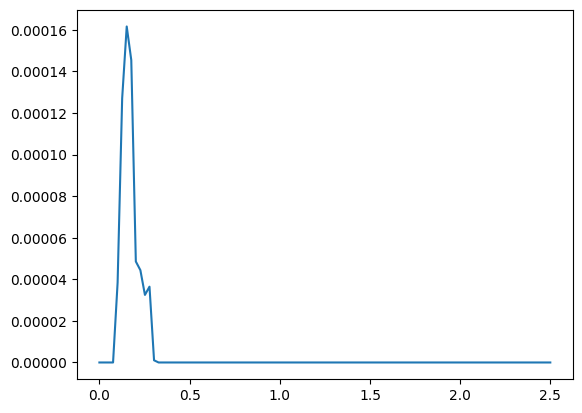

In [103]:
plt.plot(xaxis[0,:],interp_csm[0,:])

In [104]:
csm_abel = np.array(csm_abel)

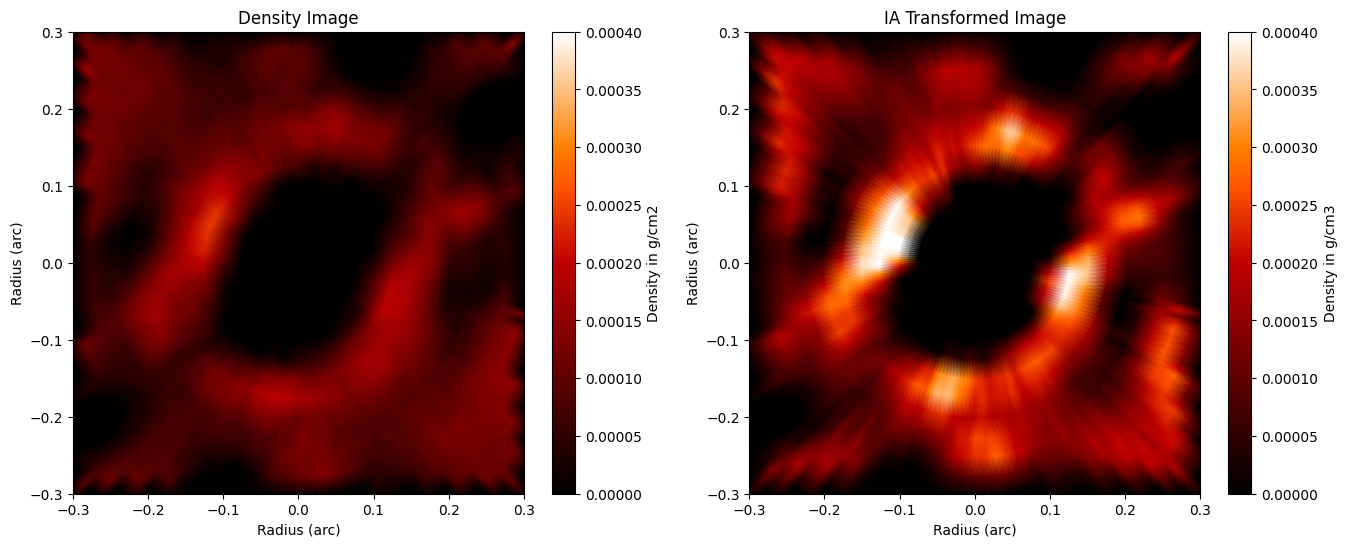

In [105]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))

im0 = ax[0].pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0004)

rnge = 0.3
ax[0].set_xlim(-rnge,rnge)
ax[0].set_ylim(-rnge,rnge)
ax[0].set_xlabel("Radius (arc)")
ax[0].set_ylabel("Radius (arc)")

ax[0].set_title("Density Image")
fig.colorbar(im0,label = "Density in g/cm2")

### abel image

im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0004)

ax[1].set_xlim(-rnge,rnge)
ax[1].set_ylim(-rnge,rnge)
ax[1].set_xlabel("Radius (arc)")
ax[1].set_ylabel("Radius (arc)")


ax[1].set_title("IA Transformed Image")
fig.colorbar(im1,label = "Density in g/cm3")

In [106]:
np.min(csm_abel)

-0.00046654363056265616

/var/folders/ly/x_9nwhsj0y7c7t4jnvrlhzzm0000gn/T/ipykernel_79057/664715605.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


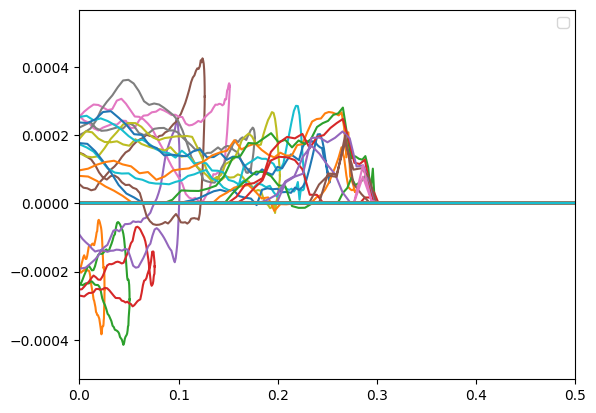

In [107]:
plt.plot(xaxis,csm_abel)
plt.xlim(0,0.5)
plt.legend()